In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

PROJECT_DIR = "/content/drive/MyDrive/Concrete_defects_CNN_v2"
DATA_DIR = os.path.join(PROJECT_DIR, "Data")
DATASET_DIR = os.path.join(DATA_DIR, "dacl1k_raw")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
GRADCAM_DIR = os.path.join(DATA_DIR, "gradcam_outputs")
os.makedirs(GRADCAM_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# labels
CLEAN_CSV = os.path.join(DATASET_DIR, "annotations_clean.csv")
csv_candidates = [f for f in os.listdir(DATASET_DIR) if f.endswith(".csv")]
LABELS_CSV = CLEAN_CSV if os.path.exists(CLEAN_CSV) else os.path.join(DATASET_DIR, csv_candidates[0])
df = pd.read_csv(LABELS_CSV)

known_meta_cols = {"img_name", "img_path", "CLASSES", "CLASSES_N", "CLASSES_STRING",
                   "isStatusChanged", "split", "split_bikit", "split_type",
                   "N_Classes", "n_classes", "num_labels"}
label_cols = [c for c in df.columns
              if c not in known_meta_cols and pd.api.types.is_numeric_dtype(df[c])]
split_col = "split_type"
assert split_col in df.columns, f"'{split_col}' not found in columns: {df.columns.tolist()}"
path_col = "img_path" if "img_path" in df.columns else "img_name"
NUM_CLASSES = len(label_cols)

test_df = df[df[split_col] == "test"].reset_index(drop=True)

# tuned thresholds from 04_testing.ipynb
thresholds_path = os.path.join(DATA_DIR, "best_thresholds.json")
with open(thresholds_path) as f:
    best_thresholds = json.load(f)
print("Thresholds:", best_thresholds)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Thresholds: {'NoDamage': 0.3, 'Crack': 0.35000000000000003, 'Efflorescence': 0.35000000000000003, 'Rust': 0.2, 'Spallation': 0.2, 'BarsExposed': 0.35000000000000003}


In [3]:
def build_resnet18(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_resnet18(NUM_CLASSES)
ckpt = torch.load(os.path.join(CHECKPOINT_DIR, "resnet18_finetuned_best.pt"), map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model = model.to(device)
model.eval()
print("Loaded checkpoint from epoch", ckpt["epoch"] + 1)

Loaded checkpoint from epoch 6


In [4]:
IMG_SIZE = 224
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

def resolve_path(rel_path):
    if rel_path.startswith("dacl1k/"):
        rel_path = rel_path[len("dacl1k/"):]
    return os.path.join(DATASET_DIR, rel_path)

In [5]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, class_idx]
        score.backward()

        pooled_gradients = self.gradients.mean(dim=[0, 2, 3])
        activations = self.activations[0]
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]

        heatmap = activations.mean(dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap = heatmap / (heatmap.max() + 1e-8)
        return heatmap, torch.sigmoid(output).detach().cpu().numpy()[0]

gradcam = GradCAM(model, model.layer4[-1])

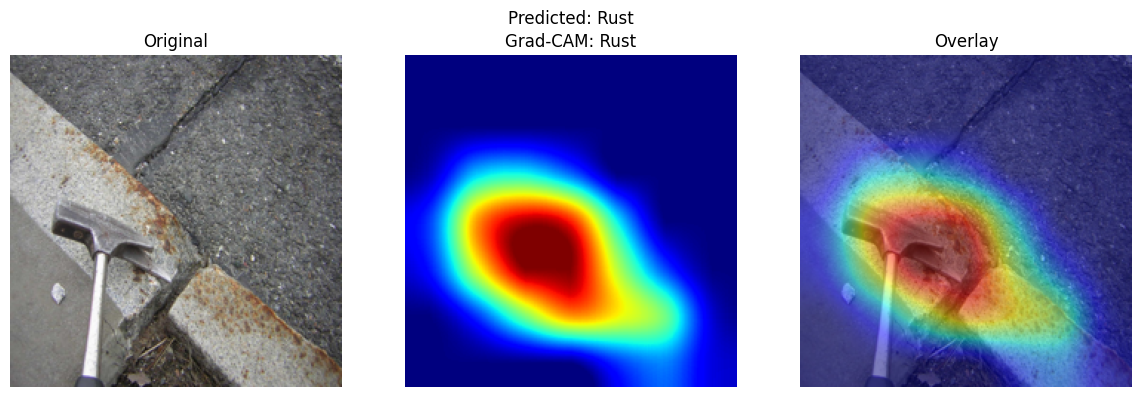

{'probs': {'NoDamage': 0.0012121166801080108, 'Crack': 0.1206403523683548, 'Efflorescence': 0.19411389529705048, 'Rust': 0.8668081760406494, 'Spallation': 0.1432647556066513, 'BarsExposed': 0.0036104051396250725}, 'predicted': ['Rust']}


In [6]:
def predict_and_explain(img_path, show=True, save_path=None):
    img = Image.open(img_path).convert("RGB")
    input_tensor = eval_transform(img).unsqueeze(0).to(device)
    input_tensor.requires_grad_()

    # first pass to get predictions
    with torch.no_grad():
        probs = torch.sigmoid(model(input_tensor)).cpu().numpy()[0]

    predicted_classes = [label_cols[i] for i in range(NUM_CLASSES) if probs[i] > best_thresholds[label_cols[i]]]
    if not predicted_classes:
        predicted_classes = ["NoDamage"]  # fallback display, model found nothing above threshold

    # Grad-CAM for the highest-scoring predicted class (or top class overall if none passed threshold)
    target_idx = int(np.argmax(probs))
    heatmap, _ = gradcam.generate(input_tensor, target_idx)

    heatmap_resized = np.array(Image.fromarray((heatmap * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE)))
    heatmap_colored = cm.jet(heatmap_resized / 255.0)[:, :, :3]

    img_resized = np.array(img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    overlay = 0.5 * img_resized + 0.5 * heatmap_colored

    if show:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(img_resized); axes[0].set_title("Original"); axes[0].axis("off")
        axes[1].imshow(heatmap_resized, cmap="jet"); axes[1].set_title(f"Grad-CAM: {label_cols[target_idx]}"); axes[1].axis("off")
        axes[2].imshow(overlay); axes[2].set_title("Overlay"); axes[2].axis("off")
        plt.suptitle(f"Predicted: {', '.join(predicted_classes)}")
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=100, bbox_inches="tight")
        plt.show()

    return {"probs": dict(zip(label_cols, probs.tolist())), "predicted": predicted_classes}

# try it on one test image
sample_path = resolve_path(test_df[path_col].iloc[0])
result = predict_and_explain(sample_path, save_path=os.path.join(GRADCAM_DIR, "sample_0.png"))
print(result)

In [7]:
n_samples = 6
for i in range(n_samples):
    img_path = resolve_path(test_df[path_col].iloc[i])
    save_path = os.path.join(GRADCAM_DIR, f"sample_{i}.png")
    result = predict_and_explain(img_path, save_path=save_path)
    print(f"sample_{i}: predicted={result['predicted']}")

print("\nSaved Grad-CAM visualizations to:", GRADCAM_DIR)

Output hidden; open in https://colab.research.google.com to view.

In [8]:
print(test_df[label_cols].iloc[:6])

   NoDamage  Crack  Efflorescence  Rust  Spallation  BarsExposed
0       0.0    0.0            0.0   1.0         1.0          0.0
1       0.0    0.0            0.0   1.0         1.0          0.0
2       0.0    0.0            0.0   1.0         1.0          0.0
3       0.0    0.0            0.0   1.0         1.0          0.0
4       0.0    0.0            0.0   1.0         1.0          0.0
5       0.0    0.0            0.0   1.0         1.0          0.0


In [ ]:
# upload a file via the Colab file picker, or set NEW_IMAGE_PATH to any path (e.g. one already on Drive)
from google.colab import files

uploaded = files.upload()  # opens a file picker; skip this cell and set NEW_IMAGE_PATH manually if you'd rather not upload interactively
NEW_IMAGE_PATH = list(uploaded.keys())[0] if uploaded else None

In [ ]:
if NEW_IMAGE_PATH:
    result = predict_and_explain(NEW_IMAGE_PATH, save_path=os.path.join(GRADCAM_DIR, "new_image_result.png"))
    print(result)